In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [27]:
df=pd.read_csv("global air pollution dataset.csv")

In [28]:
df.head(5)

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category
0,Russian Federation,Praskoveya,51,Moderate,1,Good,36,Good,0,Good,51,Moderate
1,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,41,Good
2,Italy,Priolo Gargallo,66,Moderate,1,Good,39,Good,2,Good,66,Moderate
3,Poland,Przasnysz,34,Good,1,Good,34,Good,0,Good,20,Good
4,France,Punaauia,22,Good,0,Good,22,Good,0,Good,6,Good


In [29]:
df.tail(5)

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category
23458,India,Gursahaiganj,184,Unhealthy,3,Good,154,Unhealthy,2,Good,184,Unhealthy
23459,France,Sceaux,50,Good,1,Good,20,Good,5,Good,50,Good
23460,India,Mormugao,50,Good,1,Good,22,Good,1,Good,50,Good
23461,United States of America,Westerville,71,Moderate,1,Good,44,Good,2,Good,71,Moderate
23462,Malaysia,Marang,70,Moderate,1,Good,38,Good,0,Good,70,Moderate


In [30]:
Q1 = df["PM2.5 AQI Value"].quantile(0.25)
Q3 = df["PM2.5 AQI Value"].quantile(0.75)

IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 35.0
Q3: 79.0
IQR: 44.0


In [31]:
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

Lower Limit: -31.0
Upper Limit: 145.0


In [32]:
outliers = df[
    (df["PM2.5 AQI Value"] < lower_limit) |
    (df["PM2.5 AQI Value"] > upper_limit)
]

print("Number of outliers:", len(outliers))

Number of outliers: 2641


In [47]:
df_iqr = df[
    (df["PM2.5 AQI Value"] >= lower_limit) &
    (df["PM2.5 AQI Value"] <= upper_limit)
].copy()
print("Original shape:", df.shape)
print("New shape:", df_iqr.shape)

Original shape: (23463, 12)
New shape: (20822, 12)


In [48]:
X = df_iqr[['PM2.5 AQI Value']]
y = df_iqr['AQI Value']

In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [50]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(16657, 1)
(4165, 1)
(16657,)
(4165,)


In [51]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [52]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [53]:
print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)

Coefficient: 0.921696862620174
Intercept: 7.510386199063284


In [54]:
y_pred = model.predict(X_test)

In [55]:
print(y_pred[:5])

[44.3782607  35.16129208 28.70941404 48.06504815 34.23959522]


In [56]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

print(comparison.head(10))

   Actual   Predicted
0      40   44.378261
1      30   35.161292
2      23   28.709414
3      44   48.065048
4      29   34.239595
5      65   67.420682
6     110  108.897041
7      18   17.649052
8      51   54.516926
9      61   63.733895


In [57]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 4.852466006187045
MSE: 74.31454580107564
RMSE: 8.620588483454922
R² Score: 0.9033257129957897


In [58]:
print("Regression Equation:")
print(f"AQI Value = {model.intercept_:.2f} + ({model.coef_[0]:.2f} × PM2.5 AQI Value)")

Regression Equation:
AQI Value = 7.51 + (0.92 × PM2.5 AQI Value)


In [59]:
residuals = y_test - y_pred
print(residuals.head())

2831    -4.378261
17592   -5.161292
17574   -5.709414
10644   -4.065048
10548   -5.239595
Name: AQI Value, dtype: float64


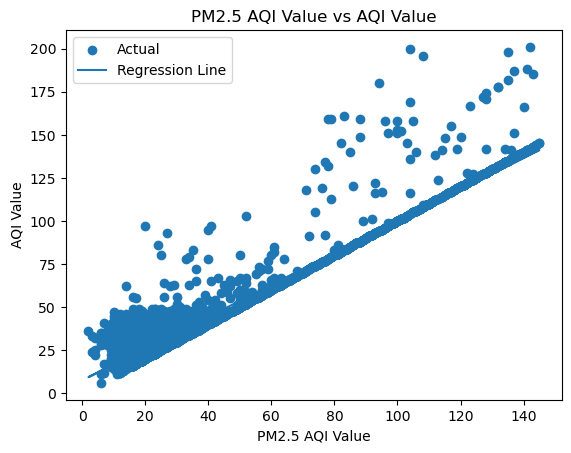

In [60]:
plt.scatter(X_test, y_test, label="Actual")
plt.plot(X_test, y_pred, label="Regression Line")
plt.xlabel("PM2.5 AQI Value")
plt.ylabel("AQI Value")
plt.title("PM2.5 AQI Value vs AQI Value")
plt.legend()
plt.show()